<a href="https://colab.research.google.com/github/asmaalbarj-2004/DS_2025/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo


========= Dataset summary ========= 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB

========= A few first samples ========= 

   fixed acidity  volatile acidity  citric a

/tmp/ipython-input-2194289262.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


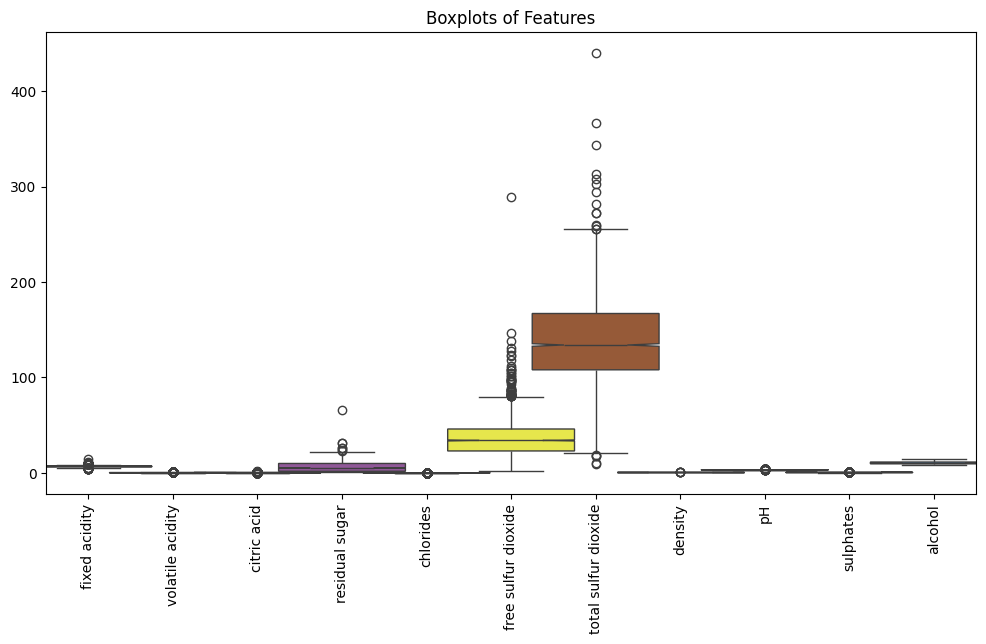

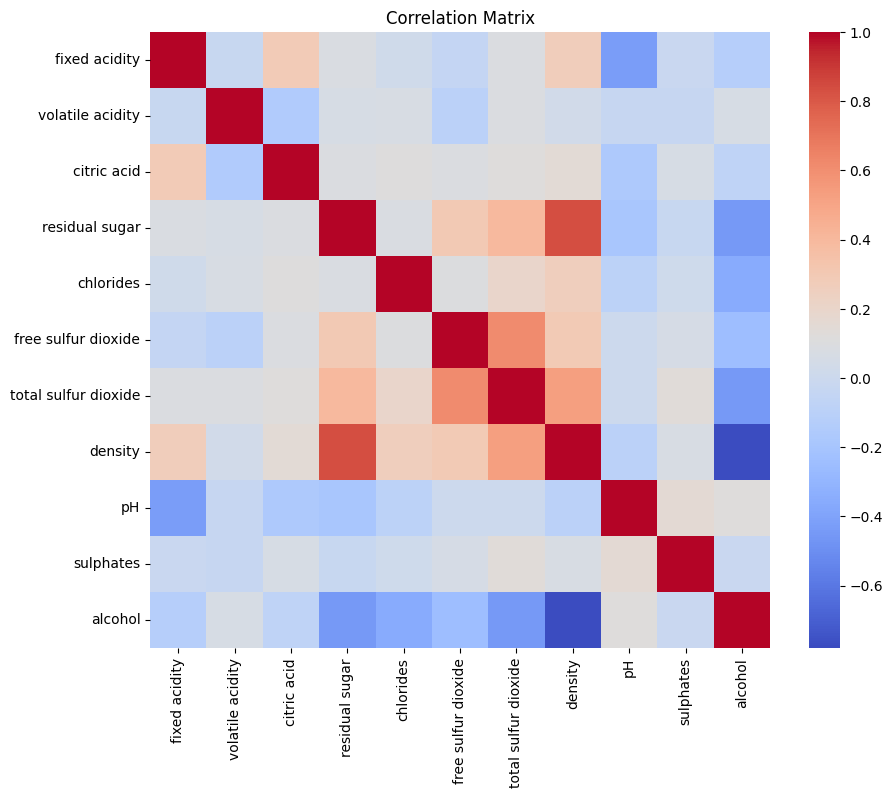


========= Dataset sizes =========

Training set: 1632 samples
Validation set: 1633 samples
Test set: 1633 samples

========= k-NN Results (k = 3) =========

Validation Error Rate: 0.3337
Validation Accuracy:   0.6663


In [2]:
# ============================================
# 0. IMPORTS
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# ============================================


# ============================================
# 1. LOAD DATASET
# ============================================
link = "http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df = pd.read_csv(link, header="infer", delimiter=";")

print("\n========= Dataset summary ========= \n")
df.info()

print("\n========= A few first samples ========= \n")
print(df.head())


# ============================================
# 2. FORM X AND Y
# ============================================
X = df.drop("quality", axis=1)
Y = df["quality"]

print("\n========= Wine Qualities ========= \n")
print(Y.value_counts())


# ============================================
# 3. BINARY CLASSIFICATION (0 = bad, 1 = good)
# ============================================
Y = np.array([0 if q <= 5 else 1 for q in Y])

print("\n========= Number of samples per class ========= \n")
unique, counts = np.unique(Y, return_counts=True)
print(dict(zip(unique, counts)))


# ============================================
# 4. STATISTICAL ANALYSIS
# ============================================

# --- Boxplots of features ---
plt.figure(figsize=(12,6))
ax = plt.gca()
sns.boxplot(data=X, orient="v", palette="Set1", width=1.5, notch=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title("Boxplots of Features")
plt.show()

# --- Correlation matrix ---
plt.figure(figsize=(10,8))
corr = X.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# ============================================
# 5. TRAIN/VAL/TEST SPLIT (STRATIFIED)
# ============================================

# First: train + test (1/3)
Xa, Xt, Ya, Yt = train_test_split(
    X, Y,
    shuffle=True,
    test_size=1/3,
    stratify=Y
)

# Second: split train into train (50%) and validation (50%)
Xa, Xv, Ya, Yv = train_test_split(
    Xa, Ya,
    shuffle=True,
    test_size=0.5,
    stratify=Ya
)

print("\n========= Dataset sizes =========\n")
print(f"Training set: {Xa.shape[0]} samples")
print(f"Validation set: {Xv.shape[0]} samples")
print(f"Test set: {Xt.shape[0]} samples")


# ============================================
# 6. k-NN CLASSIFICATION (k = 3)
# ============================================

k = 3
clf = KNeighborsClassifier(n_neighbors=k)

# Train on (Xa, Ya)
clf.fit(Xa, Ya)

# Predict on validation set
Yv_pred = clf.predict(Xv)

# Error rate
error_rate = np.mean(Yv_pred != Yv)
accuracy = accuracy_score(Yv, Yv_pred)

print("\n========= k-NN Results (k = 3) =========\n")
print(f"Validation Error Rate: {error_rate:.4f}")
print(f"Validation Accuracy:   {accuracy:.4f}")


# Task
Add more plots for better data visualization, including histograms for each feature in `X`, and display the correlation matrix with numerical annotations.

## Add more plots

### Subtask:
Add additional plots for better data visualization, specifically histograms for each feature in `X`.


**Reasoning**:
To visualize the distribution of each feature in the `X` DataFrame, I will create histograms for each column. I will iterate through the columns of `X` and use `seaborn.histplot` to generate the histograms.




========= Histograms of Features =========



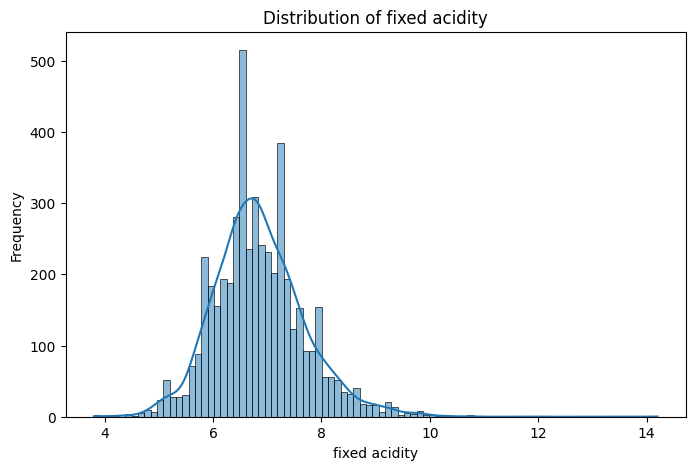

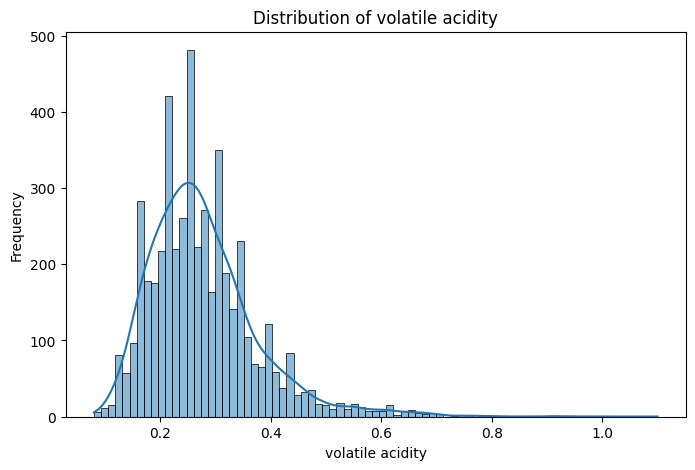

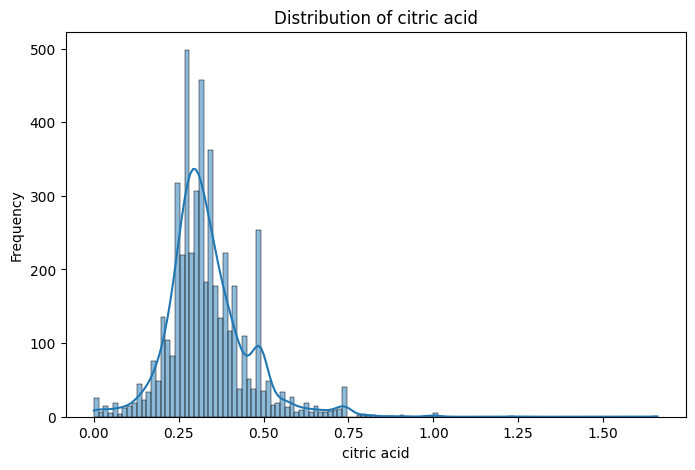

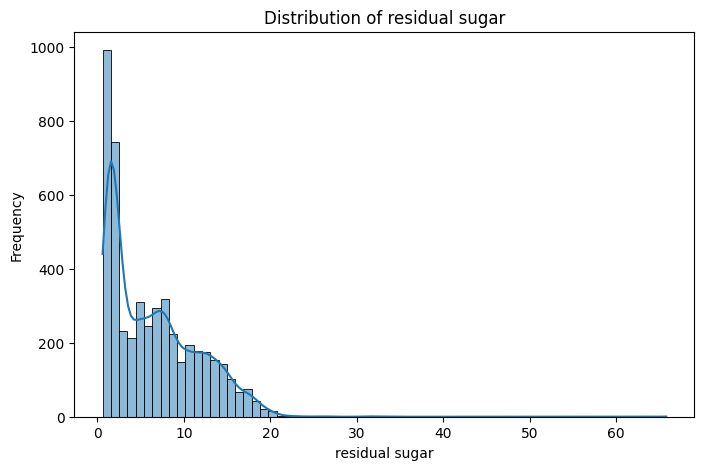

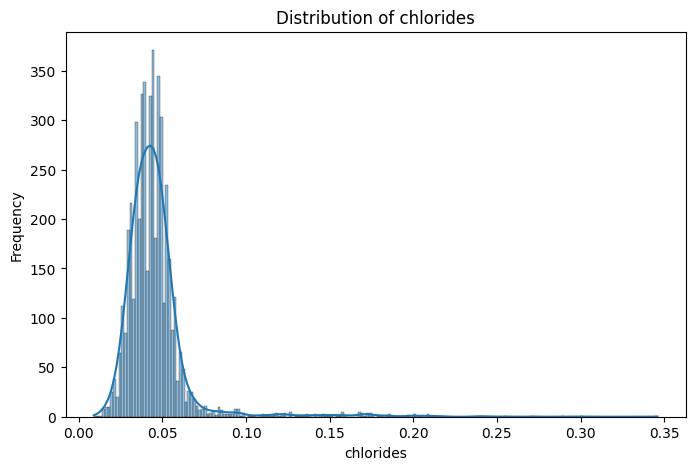

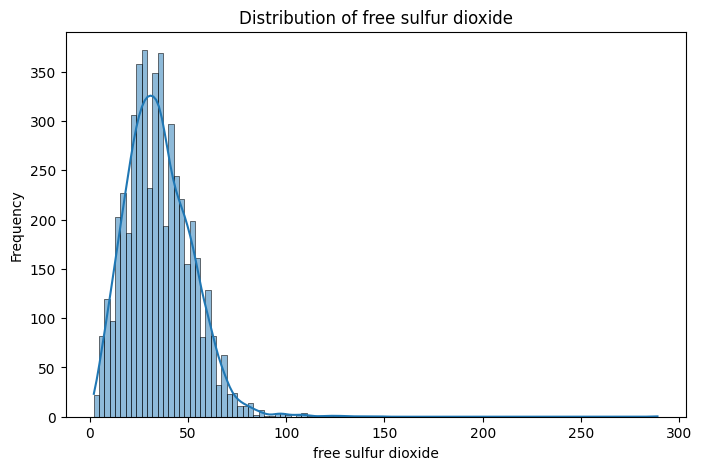

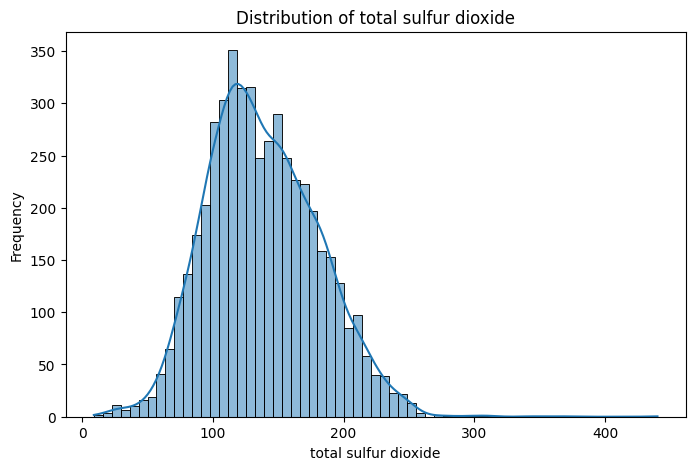

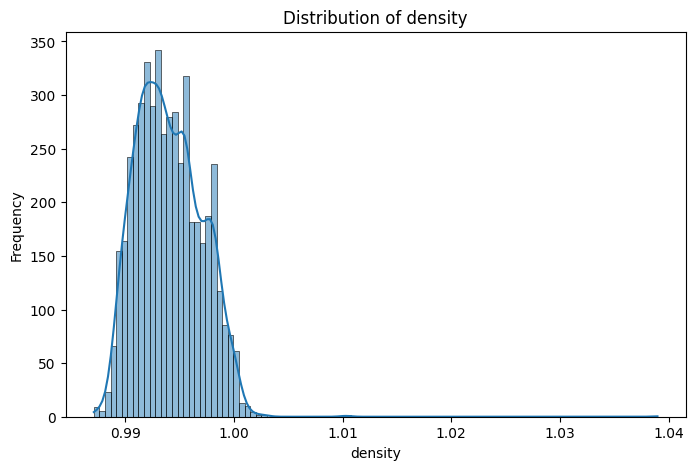

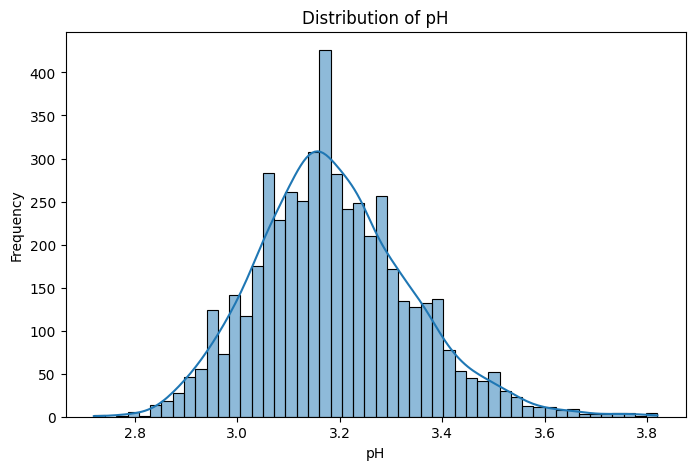

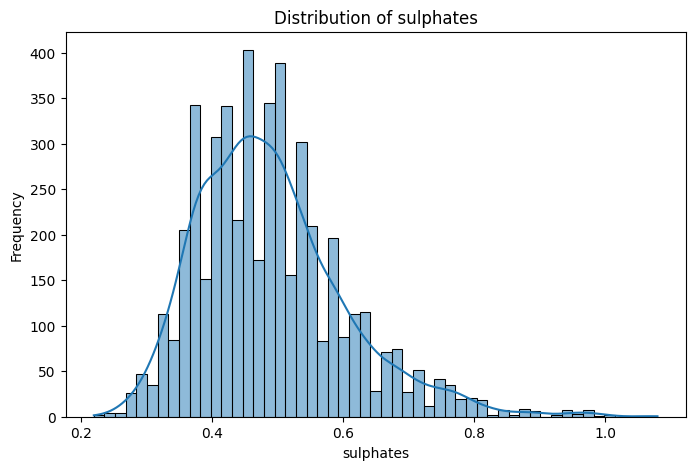

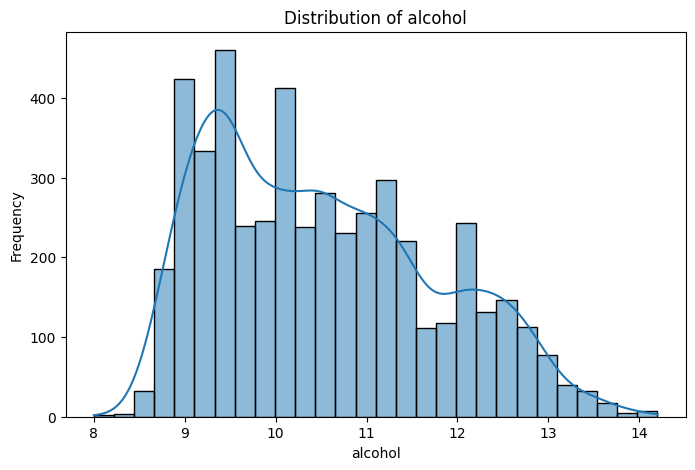

In [3]:
print("\n========= Histograms of Features =========\n")
for column in X.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(X[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

**Reasoning**:
Now that the histograms for each feature have been generated, the next step is to display the correlation matrix with numerical annotations, as requested in the task. This involves re-plotting the heatmap with the `annot=True` parameter.




========= Correlation Matrix with Annotations =========



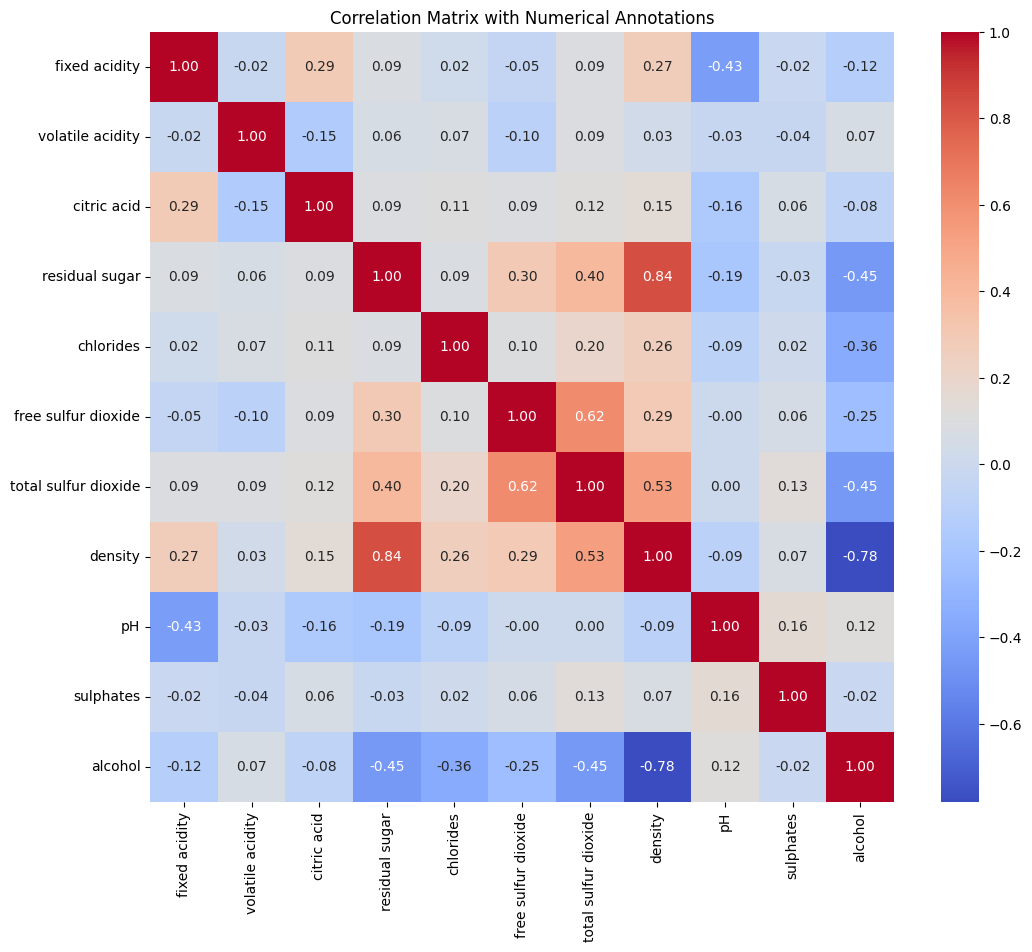

In [4]:
print("\n========= Correlation Matrix with Annotations =========\n")
plt.figure(figsize=(12,10))
corr = X.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix with Numerical Annotations")
plt.show()

## Summary:

### Data Analysis Key Findings
*   Histograms were successfully generated for each feature in the `X` DataFrame, providing a visualization of the distribution of each variable, including a Kernel Density Estimate (KDE).
*   A correlation matrix heatmap was generated and displayed, showing the pairwise correlations between features in `X` with numerical annotations for better interpretability.

### Insights or Next Steps
*   The histograms provide a clear view of the data distribution for each feature, which can help in identifying skewness, outliers, or multimodal patterns, informing potential data transformation needs.
*   The correlation matrix highlights relationships between features, which is crucial for understanding multicollinearity, feature selection, and potential feature engineering in subsequent modeling steps.
